<a href="https://colab.research.google.com/github/juanigr/Angulos-Criticos-entre-Conos-Convexos/blob/main/code/1_data_wrangling_tidyverse.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!apt-get -qq update
!apt-get -qq install -y r-base r-base-dev
!pip -q install rpy2
%load_ext rpy2.ipython

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
W: Failed to fetch https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu/dists/jammy/InRelease  Could not connect to ppa.launchpadcontent.net:443 (185.125.190.80), connection timed out
W: Failed to fetch https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu/dists/jammy/InRelease  Unable to connect to ppa.launchpadcontent.net:443:
W: Some index files failed to download. They have been ignored, or old ones used instead.


In [2]:
%%R
install_if_missing <- function(pkgs) {
  to_install <- pkgs[!pkgs %in% installed.packages()[, "Package"]]
  if (length(to_install) > 0) {
    install.packages(to_install, repos = "https://cloud.r-project.org")
  }
}

install_if_missing(c("tidyverse", "nycflights13"))

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)
trying URL 'https://cloud.r-project.org/src/contrib/nycflights13_1.0.2.tar.gz'
Content type 'application/x-gzip' length 4504033 bytes (4.3 MB)
downloaded 4.3 MB


The downloaded source packages are in
	‘/tmp/Rtmp7jIotL/downloaded_packages’


In [7]:
%%R
library(tidyverse)
library(nycflights13)
library(ggplot2)
library(dplyr)
library(tidyr)


In [9]:
%%R
data(flights)

# Ver las primeras filas
head(flights)


flights %>%
  filter(dep_delay > 60)

flights %>%
  filter(dep_delay <= 0)

flights %>%
  filter(month == 1)

flights %>%
  filter(carrier == "AA")

flights %>%
  filter(month == 1, dep_delay > 30)

# A tibble: 3,350 × 19
    year month   day dep_time sched_dep_time dep_delay arr_time sched_arr_time
   <int> <int> <int>    <int>          <int>     <dbl>    <int>          <int>
 1  2013     1     1      732            645        47     1011            941
 2  2013     1     1      749            710        39      939            850
 3  2013     1     1      811            630       101     1047            830
 4  2013     1     1      826            715        71     1136           1045
 5  2013     1     1      848           1835       853     1001           1950
 6  2013     1     1      903            820        43     1045            955
 7  2013     1     1      909            810        59     1331           1315
 8  2013     1     1      953            921        32     1320           1241
 9  2013     1     1      957            733       144     1056            853
10  2013     1     1     1025            951        34     1258           1302
# ℹ 3,340 more rows
# ℹ 11 mo

In [10]:
%%R
flights_seleccionado <- flights %>%
  select(
    year, month, day,
    dep_delay, arr_delay,
    carrier, origin, dest,
    distance, air_time
  )
n_original <- nrow(flights_seleccionado)
n_original

[1] 336776


In [11]:
%%R
flights_limpio <- flights_seleccionado %>%
  drop_na(dep_delay, arr_delay, air_time) #discusión de cuales son las variables críticas
n_limpio <- nrow(flights_limpio)
n_limpio

[1] 327346


In [12]:
%%R
observaciones_perdidas <- n_original - n_limpio
observaciones_perdidas

[1] 9430


In [14]:
%%R
porcentaje_perdido <- observaciones_perdidas / n_original * 100
porcentaje_perdido


# Se pierde una proporción pequeña de la base de datos, un 2.8%.
# Estas observaciones pueden corresponder a vuelos cancelados, desviados o con información incompleta.
# Por lo tanto, al eliminarlas, el análisis queda enfocado principalmente
# en vuelos que efectivamente tienen información completa de salida, llegada
# y tiempo en el aire.


[1] 2.800081


In [15]:
%%R
# continuamos desde el dataset limpio usando mutate:

flights_variables <- flights_limpio %>%
  mutate(
    gain = dep_delay - arr_delay,
    speed = distance / air_time * 60,
    delay_category = case_when(
      arr_delay <= 0 ~ "temprano",
      arr_delay > 0 & arr_delay <= 30 ~ "leve",
      arr_delay > 30 ~ "severo"
    )
  )

head(flights_variables)

flights_variables %>%
  count(delay_category)

#se puede seleccionar solo algunas colummnas para verificar

flights_variables %>%
  select(dep_delay, arr_delay, air_time, speed, delay_category) %>%
  head()

# A tibble: 6 × 5
  dep_delay arr_delay air_time speed delay_category
      <dbl>     <dbl>    <dbl> <dbl> <chr>         
1         2        11      227  370. leve          
2         4        20      227  374. leve          
3         2        33      160  408. severo        
4        -1       -18      183  517. temprano      
5        -6       -25      116  394. temprano      
6        -4        12      150  288. leve          


In [20]:
%%R
resumen_carrier <- flights_variables %>%
  group_by(carrier) %>%
  summarise(
    n_vuelos = n(),
    retraso_salida_promedio = mean(dep_delay, na.rm = TRUE),
    retraso_llegada_promedio = mean(arr_delay, na.rm = TRUE),
    proporcion_atrasados = mean(arr_delay > 0, na.rm = TRUE),
    porcentaje_atrasados = proporcion_atrasados * 100,
    velocidad_promedio = mean(speed, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(desc(porcentaje_atrasados))

resumen_carrier

# A tibble: 16 × 7
   carrier n_vuelos retraso_salida_promedio retraso_llegada_promedio
   <chr>      <int>                   <dbl>                    <dbl>
 1 FL          3175                   18.6                    20.1  
 2 F9           681                   20.2                    21.9  
 3 EV         51108                   19.8                    15.8  
 4 YV           544                   18.9                    15.6  
 5 MQ         25037                   10.4                    10.8  
 6 WN         12044                   17.7                     9.65 
 7 B6         54049                   13.0                     9.46 
 8 UA         57782                   12.0                     3.56 
 9 9E         17294                   16.4                     7.38 
10 US         19831                    3.74                    2.13 
11 OO            29                   12.6                    11.9  
12 DL         47658                    9.22                    1.64 
13 VX          

In [22]:
%%R
resumen_month <- flights_variables %>%
  group_by(month) %>%
  summarise(
    n_vuelos = n(),
    retraso_salida_promedio = mean(dep_delay, na.rm = TRUE),
    retraso_llegada_promedio = mean(arr_delay, na.rm = TRUE),
    proporcion_atrasados = mean(arr_delay > 0, na.rm = TRUE),
    porcentaje_atrasados = proporcion_atrasados * 100,
    velocidad_promedio = mean(speed, na.rm = TRUE),
    .groups = "drop"
  )

resumen_month


# A tibble: 12 × 7
   month n_vuelos retraso_salida_promedio retraso_llegada_promedio
   <int>    <int>                   <dbl>                    <dbl>
 1     1    26398                    9.99                    6.13 
 2     2    23611                   10.8                     5.61 
 3     3    27902                   13.2                     5.81 
 4     4    27564                   13.8                    11.2  
 5     5    28128                   12.9                     3.52 
 6     6    27075                   20.7                    16.5  
 7     7    28293                   21.5                    16.7  
 8     8    28756                   12.6                     6.04 
 9     9    27010                    6.63                   -4.02 
10    10    28618                    6.23                   -0.167
11    11    26971                    5.42                    0.461
12    12    27020                   16.5                    14.9  
# ℹ 3 more variables: proporcion_atrasados 

In [24]:
%%R

peor_retraso <- resumen_carrier %>%
  arrange(desc(retraso_llegada_promedio))

peor_retraso

# A tibble: 16 × 7
   carrier n_vuelos retraso_salida_promedio retraso_llegada_promedio
   <chr>      <int>                   <dbl>                    <dbl>
 1 F9           681                   20.2                    21.9  
 2 FL          3175                   18.6                    20.1  
 3 EV         51108                   19.8                    15.8  
 4 YV           544                   18.9                    15.6  
 5 OO            29                   12.6                    11.9  
 6 MQ         25037                   10.4                    10.8  
 7 WN         12044                   17.7                     9.65 
 8 B6         54049                   13.0                     9.46 
 9 9E         17294                   16.4                     7.38 
10 UA         57782                   12.0                     3.56 
11 US         19831                    3.74                    2.13 
12 VX          5116                   12.8                     1.76 
13 DL         4

In [25]:
%%R

library(nycflights13)

peor_retraso <- resumen_carrier %>%
  left_join(airlines, by = "carrier") %>%
  arrange(desc(retraso_llegada_promedio))

peor_retraso %>%
  select(
    carrier,
    name,
    n_vuelos,
    retraso_llegada_promedio,
    porcentaje_atrasados
  ) %>%
  slice_head(n = 5)

# A tibble: 5 × 5
  carrier name              n_vuelos retraso_llegada_prom…¹ porcentaje_atrasados
  <chr>   <chr>                <int>                  <dbl>                <dbl>
1 F9      Frontier Airline…      681                   21.9                 57.6
2 FL      AirTran Airways …     3175                   20.1                 59.7
3 EV      ExpressJet Airli…    51108                   15.8                 47.9
4 YV      Mesa Airlines In…      544                   15.6                 47.4
5 OO      SkyWest Airlines…       29                   11.9                 34.5
# ℹ abbreviated name: ¹​retraso_llegada_promedio


In [26]:
%%R

peor_retraso <- resumen_carrier %>%
  left_join(airlines, by = "carrier") %>%
  arrange(desc(retraso_llegada_promedio))

peor_retraso %>%
  select(
    carrier,
    name,
    n_vuelos,
    retraso_llegada_promedio,
    porcentaje_atrasados
  ) %>%
  slice_head(n = 5)


# A tibble: 5 × 5
  carrier name              n_vuelos retraso_llegada_prom…¹ porcentaje_atrasados
  <chr>   <chr>                <int>                  <dbl>                <dbl>
1 F9      Frontier Airline…      681                   21.9                 57.6
2 FL      AirTran Airways …     3175                   20.1                 59.7
3 EV      ExpressJet Airli…    51108                   15.8                 47.9
4 YV      Mesa Airlines In…      544                   15.6                 47.4
5 OO      SkyWest Airlines…       29                   11.9                 34.5
# ℹ abbreviated name: ¹​retraso_llegada_promedio


In [27]:
%%R
resumen_month %>%
  arrange(desc(retraso_llegada_promedio))

# A tibble: 12 × 7
   month n_vuelos retraso_salida_promedio retraso_llegada_promedio
   <int>    <int>                   <dbl>                    <dbl>
 1     7    28293                   21.5                    16.7  
 2     6    27075                   20.7                    16.5  
 3    12    27020                   16.5                    14.9  
 4     4    27564                   13.8                    11.2  
 5     1    26398                    9.99                    6.13 
 6     8    28756                   12.6                     6.04 
 7     3    27902                   13.2                     5.81 
 8     2    23611                   10.8                     5.61 
 9     5    28128                   12.9                     3.52 
10    11    26971                    5.42                    0.461
11    10    28618                    6.23                   -0.167
12     9    27010                    6.63                   -4.02 
# ℹ 3 more variables: proporcion_atrasados 

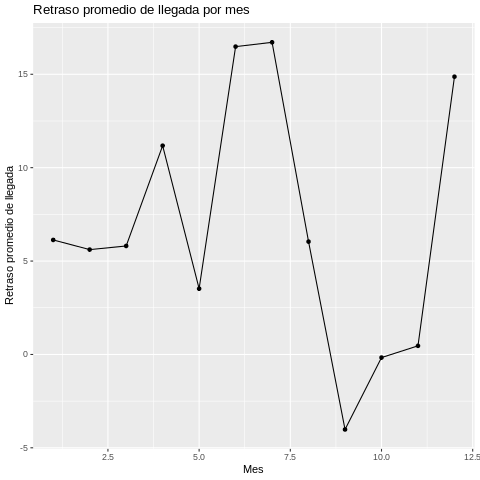

In [28]:
%%R
ggplot(resumen_month, aes(x = month, y = retraso_llegada_promedio)) +
  geom_line() +
  geom_point() +
  labs(
    title = "Retraso promedio de llegada por mes",
    x = "Mes",
    y = "Retraso promedio de llegada"
  )


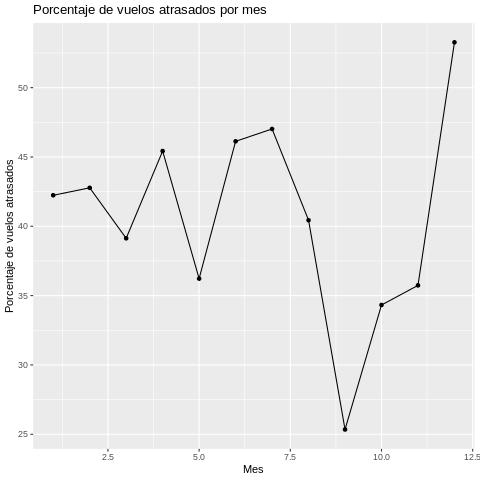

In [29]:
%%R
ggplot(resumen_month, aes(x = month, y = porcentaje_atrasados)) +
  geom_line() +
  geom_point() +
  labs(
    title = "Porcentaje de vuelos atrasados por mes",
    x = "Mes",
    y = "Porcentaje de vuelos atrasados"
  )

In [31]:
%%R
aerolineas_eficientes <- resumen_carrier %>%
  left_join(airlines, by = "carrier") %>%
  arrange(retraso_llegada_promedio, desc(velocidad_promedio))

aerolineas_eficientes %>%
  select(
    carrier,
    name,
    n_vuelos,
    retraso_llegada_promedio,
    porcentaje_atrasados,
    velocidad_promedio
  )

# A tibble: 16 × 6
   carrier name             n_vuelos retraso_llegada_prom…¹ porcentaje_atrasados
   <chr>   <chr>               <int>                  <dbl>                <dbl>
 1 AS      Alaska Airlines…      709                 -9.93                  26.7
 2 HA      Hawaiian Airlin…      342                 -6.92                  28.4
 3 AA      American Airlin…    31947                  0.364                 33.5
 4 DL      Delta Air Lines…    47658                  1.64                  34.4
 5 VX      Virgin America       5116                  1.76                  34.1
 6 US      US Airways Inc.     19831                  2.13                  37.1
 7 UA      United Air Line…    57782                  3.56                  38.5
 8 9E      Endeavor Air In…    17294                  7.38                  38.4
 9 B6      JetBlue Airways     54049                  9.46                  43.7
10 WN      Southwest Airli…    12044                  9.65                  44.0
11 MQ    

In [32]:
%%R
eficiencia_carrier <- resumen_carrier %>%
  left_join(airlines, by = "carrier") %>%
  mutate(
    score_eficiencia =
      scale(velocidad_promedio)[,1] -
      scale(retraso_llegada_promedio)[,1] -
      scale(porcentaje_atrasados)[,1]
  ) %>%
  arrange(desc(score_eficiencia))

eficiencia_carrier %>%
  select(
    carrier,
    name,
    n_vuelos,
    retraso_llegada_promedio,
    porcentaje_atrasados,
    velocidad_promedio,
    score_eficiencia
  )


# A tibble: 16 × 7
   carrier name             n_vuelos retraso_llegada_prom…¹ porcentaje_atrasados
   <chr>   <chr>               <int>                  <dbl>                <dbl>
 1 HA      Hawaiian Airlin…      342                 -6.92                  28.4
 2 AS      Alaska Airlines…      709                 -9.93                  26.7
 3 VX      Virgin America       5116                  1.76                  34.1
 4 AA      American Airlin…    31947                  0.364                 33.5
 5 DL      Delta Air Lines…    47658                  1.64                  34.4
 6 UA      United Air Line…    57782                  3.56                  38.5
 7 US      US Airways Inc.     19831                  2.13                  37.1
 8 B6      JetBlue Airways     54049                  9.46                  43.7
 9 WN      Southwest Airli…    12044                  9.65                  44.0
10 OO      SkyWest Airline…       29                 11.9                   34.5
11 9E    